In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

# Load data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension
X_train = X_train[..., None]
X_test = X_test[..., None]

print(X_train.shape)

(60000, 28, 28, 1)


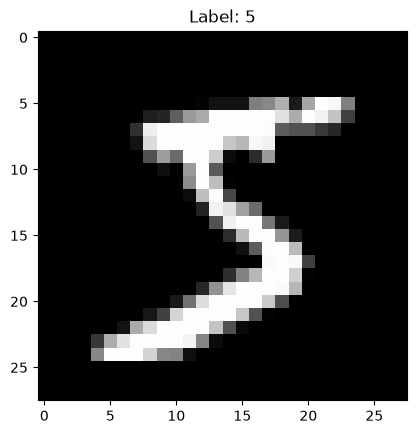

In [3]:
import matplotlib.pyplot as plt

plt.imshow(
    X_train[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Label: {y_train[0]}"
)

plt.show()

In [2]:
model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

c:\Users\Priya Koma\Desktop\AI_ML\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32
)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9947 - loss: 0.0159
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9961 - loss: 0.0116
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9973 - loss: 0.0079


In [8]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0599
Test Accuracy: 0.9850999712944031
